# Compare fine-tuned models — side-by-side diagnostics
Loads several checkpoints on the same test rollout and compares RMSE / CSI metrics.

In [1]:
import sys, os

_proj_db = r'C:\Users\marrocol\AppData\Local\miniforge3\envs\mswe-gnn\Lib\site-packages\pyproj\proj_dir\share\proj'
os.environ.setdefault('PROJ_DATA', _proj_db)
os.environ.setdefault('PROJ_LIB',  _proj_db)

try:
    REPO_ROOT = os.path.abspath(os.path.join(os.path.dirname(__vsc_ipynb_file__), '..'))
except NameError:
    REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))

os.chdir(REPO_ROOT)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import torch
import wandb
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from utils.load import read_config
from utils.miscellaneous import get_model, fix_dict_in_config
from utils.dataset import create_model_dataset, get_temporal_test_dataset_parameters, to_temporal_dataset
from utils.visualization import PlotRollout
from training.train import LightningTrainer

torch.backends.cudnn.deterministic = True
torch.set_float32_matmul_precision('high')
print('Repo root:', REPO_ROOT)

Repo root: c:\Users\marrocol\OneDrive - Stichting Deltares\Documents\mSWE-GNN\mSWE-GNN_marg\mSWE-GNN_marg


## Models to compare

In [4]:
CONFIG       = 'config_finetune_weighted_rmse.yaml'   # used only for dataset/scalers; architecture is auto-detected per checkpoint
DATASET_NAME = 'ahr_river_v03_marg_additionalsrc_velocity_100m_warmstart'

MODELS = [
    {'name': 'finetune_weighted_rmse',          'checkpoint': os.path.join(REPO_ROOT, 'results', 'finetune_weighted_rmse.h5')},
    {'name': 'best_sweep_weightedrmse',         'checkpoint': os.path.join(REPO_ROOT, 'results', 'best_sweep_weightedrmse.h5')},
    {'name': 'finetune_weighted_rmse_extended','checkpoint': os.path.join(REPO_ROOT, 'results', 'finetune_weighted_rmse_extended.h5')},
    {'name': 'best_sweep_valloss_weightedrmse', 'checkpoint': os.path.join(REPO_ROOT, 'lightning_logs', 'best_sweep_valloss_weightedrmse.ckpt')},
    {'name': 'last_sweep_valloss_weightedrmse', 'checkpoint': os.path.join(REPO_ROOT, 'lightning_logs', 'last_sweep_valloss_weightedrmse.ckpt')},
]

for m in MODELS:
    exists = os.path.exists(m['checkpoint'])
    size = f"{os.path.getsize(m['checkpoint'])/1e6:.1f} MB" if exists else 'MISSING'
    print(f"{m['name']:<32} exists={exists!s:<6} {size:>10}  {m['checkpoint']}")

finetune_weighted_rmse           exists=True       9.7 MB  c:\Users\marrocol\OneDrive - Stichting Deltares\Documents\mSWE-GNN\mSWE-GNN_marg\mSWE-GNN_marg\results\finetune_weighted_rmse.h5
best_sweep_weightedrmse          exists=True       2.5 MB  c:\Users\marrocol\OneDrive - Stichting Deltares\Documents\mSWE-GNN\mSWE-GNN_marg\mSWE-GNN_marg\results\best_sweep_weightedrmse.h5
finetune_weighted_rmse_extended  exists=True       9.7 MB  c:\Users\marrocol\OneDrive - Stichting Deltares\Documents\mSWE-GNN\mSWE-GNN_marg\mSWE-GNN_marg\results\finetune_weighted_rmse_extended.h5
best_sweep_valloss_weightedrmse  exists=True       2.5 MB  c:\Users\marrocol\OneDrive - Stichting Deltares\Documents\mSWE-GNN\mSWE-GNN_marg\mSWE-GNN_marg\lightning_logs\best_sweep_valloss_weightedrmse.ckpt
last_sweep_valloss_weightedrmse  exists=True       2.5 MB  c:\Users\marrocol\OneDrive - Stichting Deltares\Documents\mSWE-GNN\mSWE-GNN_marg\mSWE-GNN_marg\lightning_logs\last_sweep_valloss_weightedrmse.ckpt


## Load shared config and dataset
Same test rollout is reused for every model, so the comparison is apples-to-apples.

In [5]:
cfg = read_config(CONFIG)
cfg['dataset_parameters']['test_dataset_name']  = DATASET_NAME
cfg['dataset_parameters']['train_dataset_name'] = DATASET_NAME

wandb.init(mode='disabled', project='mswe-gnn', config=cfg)
fix_dict_in_config(wandb)
config = wandb.config

device = torch.device('cpu')

_, _, test_dataset, scalers = create_model_dataset(
    scalers=config.scalers, device=device,
    **config.dataset_parameters,
    **config.selected_node_features,
    **config.selected_edge_features
)

temporal_test_dataset_parameters = get_temporal_test_dataset_parameters(
    config, config.temporal_dataset_parameters
)

temporal_test_dataset = to_temporal_dataset(
    test_dataset, rollout_steps=-1, **temporal_test_dataset_parameters
)

num_node_features = temporal_test_dataset[0].x.size(-1)
num_edge_features = temporal_test_dataset[0].edge_attr.size(-1)

print('Test size:', len(test_dataset))
print('WD shape: ', test_dataset[0].WD.shape)

The validation dataset you are using is the training one. Careful!
Test size: 1
WD shape:  torch.Size([30079, 119])


## Load each checkpoint and run inference
Architecture (hid_features, K) is auto-detected from each checkpoint's state_dict.

In [6]:
def load_model_from_checkpoint(checkpoint_path):
    model_parameters = dict(config.models)
    model_type = model_parameters.pop('model_type')
    if model_type == 'MSGNN':
        model_parameters['num_scales'] = test_dataset[0].mesh.num_meshes

    ckpt = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
    sd   = ckpt['state_dict']
    hid  = sd['model.edge_encoder.0.weight'].shape[0]

    proc_ids = sorted(set(
        int(k.split('.')[2]) for k in sd
        if k.startswith('model.gnn_processor.') and 'filter_matrix.' in k
    ))
    K_list = [
        sum(1 for k in sd if f'model.gnn_processor.{i}.filter_matrix.' in k and k.endswith('.weight')) - 1
        for i in proc_ids
    ]
    model_parameters['hid_features'] = hid
    model_parameters['K']            = K_list

    model = get_model(model_type)(
        num_node_features=num_node_features,
        num_edge_features=num_edge_features,
        previous_t=temporal_test_dataset_parameters['previous_t'],
        device=device,
        **model_parameters
    ).to(device)

    plmodule_kwargs = {
        'model': model,
        'lr_info': config['lr_info'],
        'trainer_options': config.trainer_options,
        'temporal_test_dataset_parameters': temporal_test_dataset_parameters
    }
    plmodule = LightningTrainer.load_from_checkpoint(
        checkpoint_path, map_location=device, **plmodule_kwargs
    )
    model = plmodule.model.to(device)
    model.eval()
    return model, hid, K_list


results = {}
for m in MODELS:
    name, ckpt_path = m['name'], m['checkpoint']
    if not os.path.exists(ckpt_path):
        print(f'[skip] {name}: checkpoint not found at {ckpt_path}')
        continue
    print(f'Loading {name} ...')
    model, hid, K_list = load_model_from_checkpoint(ckpt_path)

    plot_rollout = PlotRollout(
        model, test_dataset[0], scalers=scalers,
        warmup_steps=0, **temporal_test_dataset_parameters
    )

    rollout_loss = plot_rollout._get_rollout_loss(type_loss='RMSE')
    loss_mean = rollout_loss.mean(0)
    rmse_wd = loss_mean[0].item() if loss_mean.ndim > 0 else loss_mean.item()

    csi_thresholds = [0.01, 0.02, 0.03, 0.05, 0.10, 0.20, 0.30, 0.50]
    csi_curve = [plot_rollout._get_CSI(water_threshold=t).nanmean().item() for t in csi_thresholds]

    csi_time_005 = plot_rollout._get_CSI(water_threshold=0.05).detach().cpu().numpy()
    csi_time_03  = plot_rollout._get_CSI(water_threshold=0.30).detach().cpu().numpy()
    if csi_time_005.ndim > 1:
        csi_time_005 = np.nanmean(csi_time_005, axis=0)
        csi_time_03  = np.nanmean(csi_time_03, axis=0)

    results[name] = {
        'hid_features': hid,
        'K': K_list,
        'rmse_wd': rmse_wd,
        'csi_005': csi_curve[csi_thresholds.index(0.05)],
        'csi_03':  csi_curve[csi_thresholds.index(0.30)],
        'csi_thresholds': csi_thresholds,
        'csi_curve': csi_curve,
        'csi_time_005': csi_time_005,
        'csi_time_03': csi_time_03,
        'plot_rollout': plot_rollout,
    }
    print(f'  hid={hid} K={K_list}  RMSE_WD={rmse_wd:.4f}  CSI@0.05={results[name]["csi_005"]:.4f}  CSI@0.30={results[name]["csi_03"]:.4f}')

Loading finetune_weighted_rmse ...
  hid=64 K=[1, 2, 2, 7, 5, 4, 3]  RMSE_WD=0.2617  CSI@0.05=0.5474  CSI@0.30=0.5875
Loading best_sweep_weightedrmse ...
  hid=32 K=[1, 1, 1, 5, 4, 3, 2]  RMSE_WD=0.2247  CSI@0.05=0.6010  CSI@0.30=0.6181
Loading finetune_weighted_rmse_extended ...
  hid=64 K=[1, 2, 2, 7, 5, 4, 3]  RMSE_WD=0.3401  CSI@0.05=0.3693  CSI@0.30=0.4877
Loading best_sweep_valloss_weightedrmse ...
  hid=32 K=[1, 1, 1, 5, 4, 3, 2]  RMSE_WD=0.1981  CSI@0.05=0.6743  CSI@0.30=0.6793
Loading last_sweep_valloss_weightedrmse ...
  hid=32 K=[1, 1, 1, 5, 4, 3, 2]  RMSE_WD=0.3335  CSI@0.05=0.5833  CSI@0.30=0.6319


## Summary table

In [7]:
header = f"{'Model':<32} {'hid':>5} {'K':>22} {'RMSE_WD':>9} {'CSI@0.05':>9} {'CSI@0.30':>9}"
print(header)
print('-' * len(header))
for name, r in results.items():
    print(f"{name:<32} {r['hid_features']:>5} {str(r['K']):>22} {r['rmse_wd']:>9.4f} {r['csi_005']:>9.4f} {r['csi_03']:>9.4f}")

Model                              hid                      K   RMSE_WD  CSI@0.05  CSI@0.30
-------------------------------------------------------------------------------------------
finetune_weighted_rmse              64  [1, 2, 2, 7, 5, 4, 3]    0.2617    0.5474    0.5875
best_sweep_weightedrmse             32  [1, 1, 1, 5, 4, 3, 2]    0.2247    0.6010    0.6181
finetune_weighted_rmse_extended     64  [1, 2, 2, 7, 5, 4, 3]    0.3401    0.3693    0.4877
best_sweep_valloss_weightedrmse     32  [1, 1, 1, 5, 4, 3, 2]    0.1981    0.6743    0.6793
last_sweep_valloss_weightedrmse     32  [1, 1, 1, 5, 4, 3, 2]    0.3335    0.5833    0.6319


## CSI vs threshold — all models

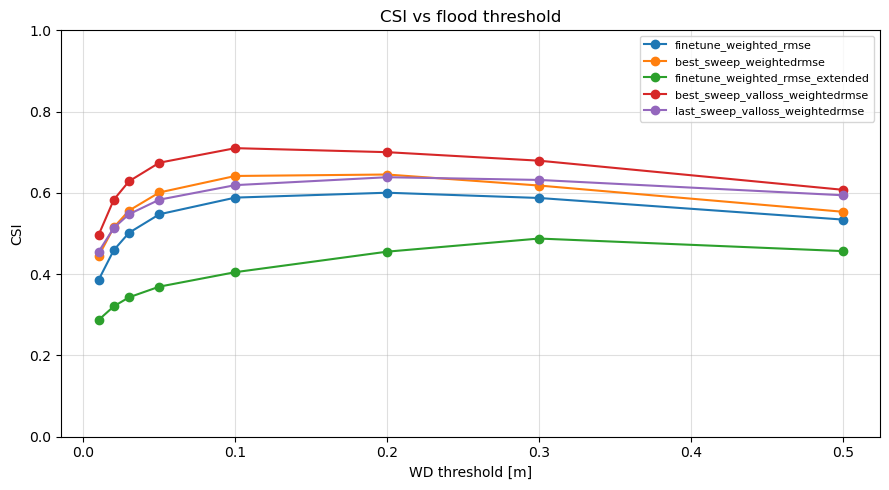

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
for name, r in results.items():
    ax.plot(r['csi_thresholds'], r['csi_curve'], 'o-', label=name)
ax.set_xlabel('WD threshold [m]')
ax.set_ylabel('CSI')
ax.set_title('CSI vs flood threshold')
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.4)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## CSI over time — all models

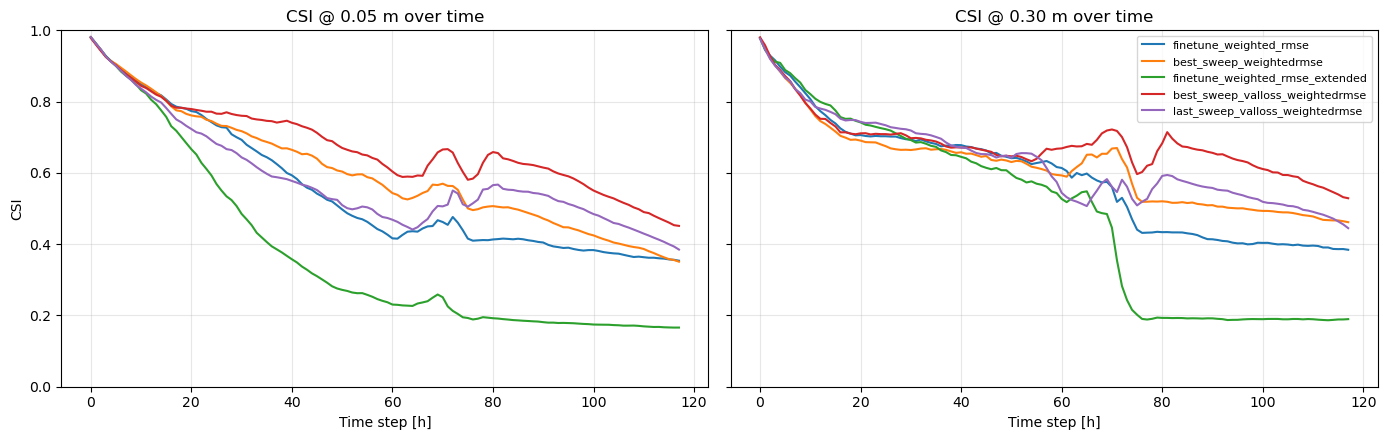

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
for name, r in results.items():
    axes[0].plot(r['csi_time_005'], label=name)
    axes[1].plot(r['csi_time_03'], label=name)
axes[0].set_title('CSI @ 0.05 m over time')
axes[1].set_title('CSI @ 0.30 m over time')
for ax in axes:
    ax.set_xlabel('Time step [h]')
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel('CSI')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

## Step-0 diagnostics — FP/FN decomposition @ 0.05 m
Determines the CSI failure mode before touching the loss:
- **Monotonic CSI decay + growing FP or FN** → rollout drift → attack rollout_steps / curriculum (plan step 2)
- **Dip on the rising limb, recovery after** → flood-front timing lag
- **FP-dominated** → over-wetting → soft-CSI/Dice penalizes false alarms directly
- **FN-dominated** → shallow depths under-predicted → shallow_weight / Dice on misses

Timesteps for the spatial maps are picked automatically from the real wet-area curve
(rising limb = half-rise, peak = max wet area, recession = half-fall).

Diagnostic timesteps (of 118): {'rising limb': 0, 'peak': 76, 'recession': 117}


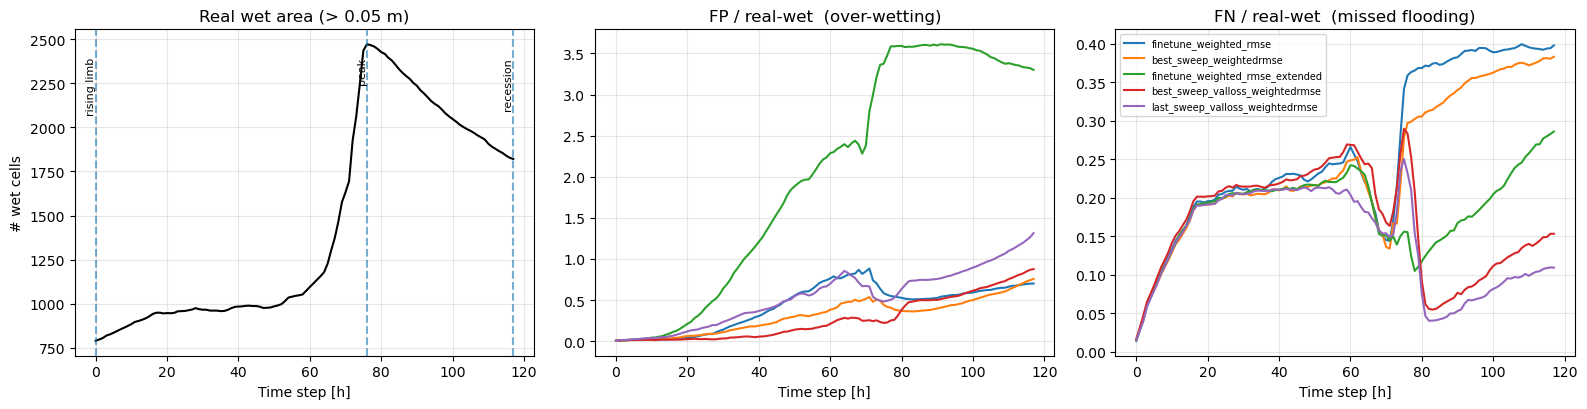

Model                             mean FP/wet  mean FN/wet  dominant error
finetune_weighted_rmse                  0.432        0.262  FP (over-wetting)
best_sweep_weightedrmse                 0.311        0.243  FP (over-wetting)
finetune_weighted_rmse_extended         2.024        0.186  FP (over-wetting)
best_sweep_valloss_weightedrmse         0.272        0.169  FP (over-wetting)
last_sweep_valloss_weightedrmse         0.539        0.146  FP (over-wetting)


In [20]:
from utils.miscellaneous import get_rollout_confusion_matrix

THR = 0.05 # m — WD_scaler is None, so rollouts are already in physical units

# Real wet area over time (identical for all models) — used to locate the flood phases
real_s0 = next(iter(results.values()))['plot_rollout']._real_rollout_s0  # [nodes, vars, time]
wet_area = (real_s0[:, 0, :] > THR).sum(0).cpu().numpy()

t_peak = int(wet_area.argmax())
base = wet_area[0]
half = base + 0.5 * (wet_area.max() - base)
rise_c = np.where(wet_area[:t_peak] <= half)[0]
t_rise = 0
rec_c = np.where(wet_area[t_peak:] <= half)[0]
t_rec = int(t_peak + rec_c[0]) if len(rec_c) else int(wet_area.shape[0] - 1)
phases = {'rising limb': t_rise, 'peak': t_peak, 'recession': t_rec}
print(f'Diagnostic timesteps (of {wet_area.shape[0]}):', phases)

conf = {}
for name, r in results.items():
    TP, TN, FP, FN = get_rollout_confusion_matrix(
        r['plot_rollout']._predicted_rollout_s0, r['plot_rollout']._real_rollout_s0,
        water_threshold=THR)
    conf[name] = dict(zip(['TP', 'TN', 'FP', 'FN'],
                          [v.cpu().numpy().astype(float) for v in (TP, TN, FP, FN)]))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
axes[0].plot(wet_area, 'k-')
for ph, t in phases.items():
    axes[0].axvline(t, ls='--', alpha=0.6)
    axes[0].annotate(ph, (t, wet_area.max() * 0.97), rotation=90, fontsize=8, ha='right', va='top')
axes[0].set_title(f'Real wet area (> {THR} m)')
axes[0].set_ylabel('# wet cells')

for name, c in conf.items():
    wet = c['TP'] + c['FN']  # real wet cells per timestep
    axes[1].plot(c['FP'] / wet, label=name)
    axes[2].plot(c['FN'] / wet, label=name)
axes[1].set_title('FP / real-wet  (over-wetting)')
axes[2].set_title('FN / real-wet  (missed flooding)')
for ax in axes:
    ax.set_xlabel('Time step [h]')
    ax.grid(alpha=0.3)
axes[2].legend(fontsize=7)
plt.tight_layout()
plt.show()

print(f"{'Model':<32} {'mean FP/wet':>12} {'mean FN/wet':>12}  dominant error")
for name, c in conf.items():
    wet = c['TP'] + c['FN']
    fp, fn = np.nanmean(c['FP'] / wet), np.nanmean(c['FN'] / wet)
    dom = 'FP (over-wetting)' if fp > fn else 'FN (under-prediction)'
    print(f"{name:<32} {fp:>12.3f} {fn:>12.3f}  {dom}")

### Spatial TP / FP / FN maps at rising limb, peak, recession
Where are the errors? Red = false alarm (predicted wet, actually dry), orange = miss (predicted dry, actually wet).
A thin FP/FN ring around the flood extent = fringe problem; FN patches in whole side valleys = front timing / drift.

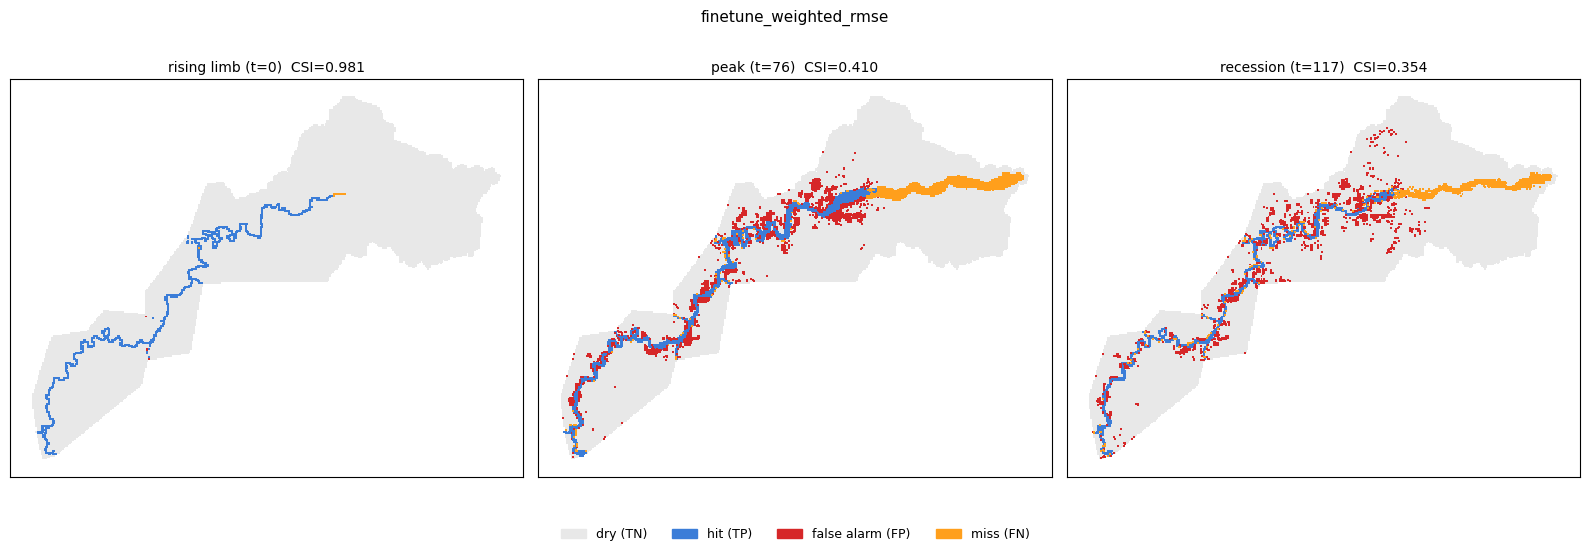

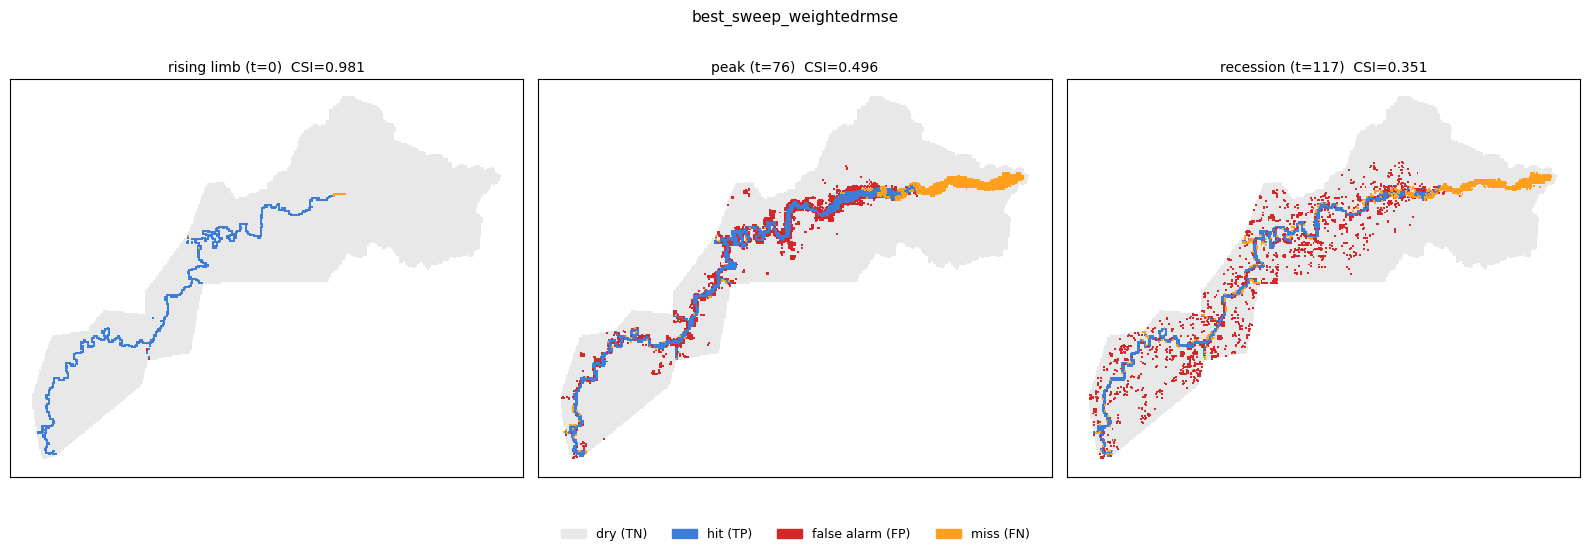

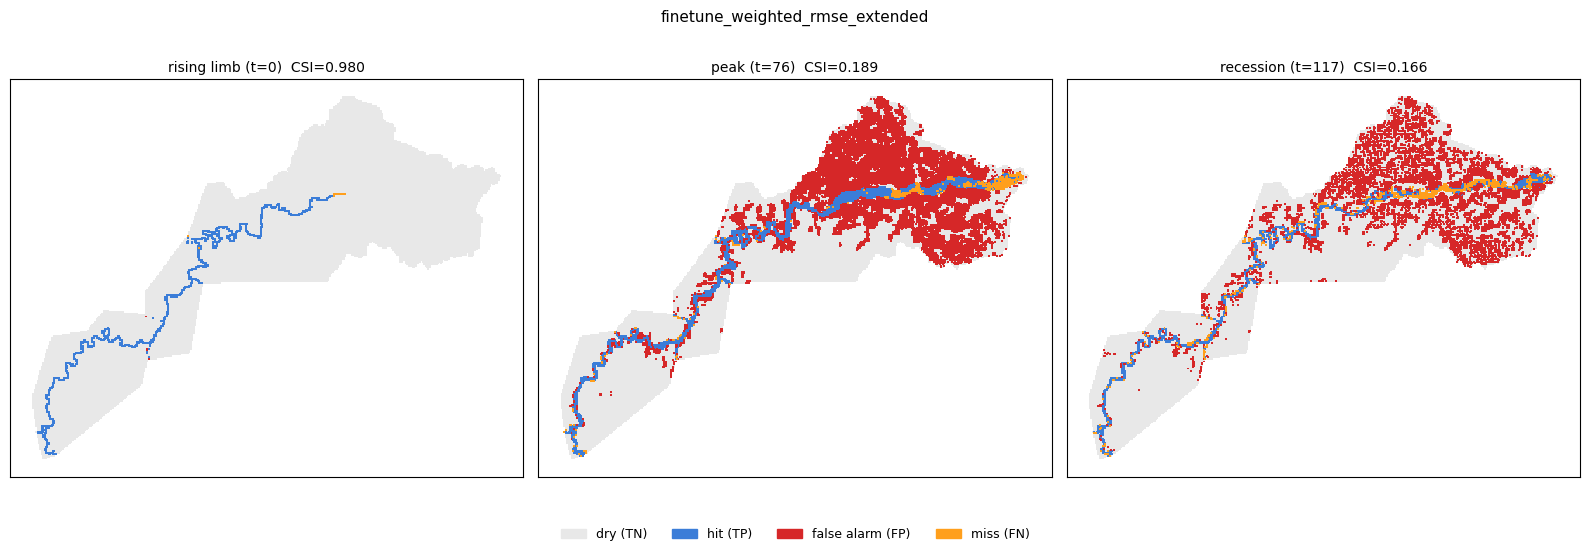

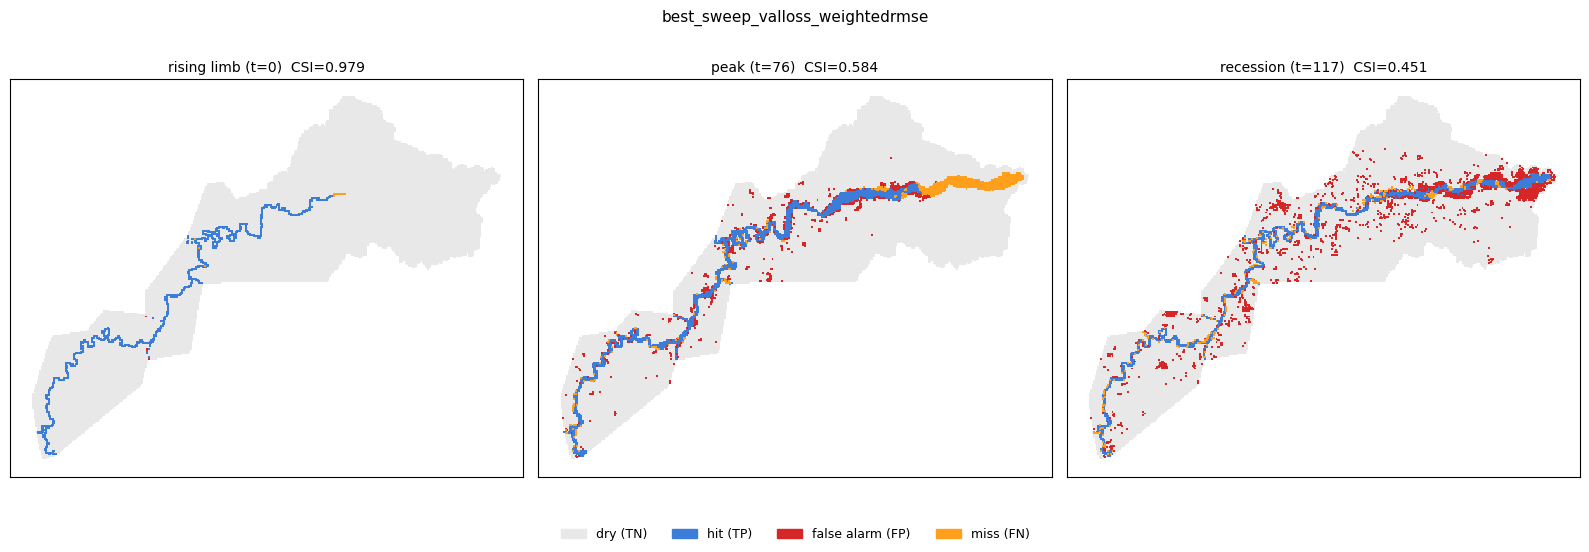

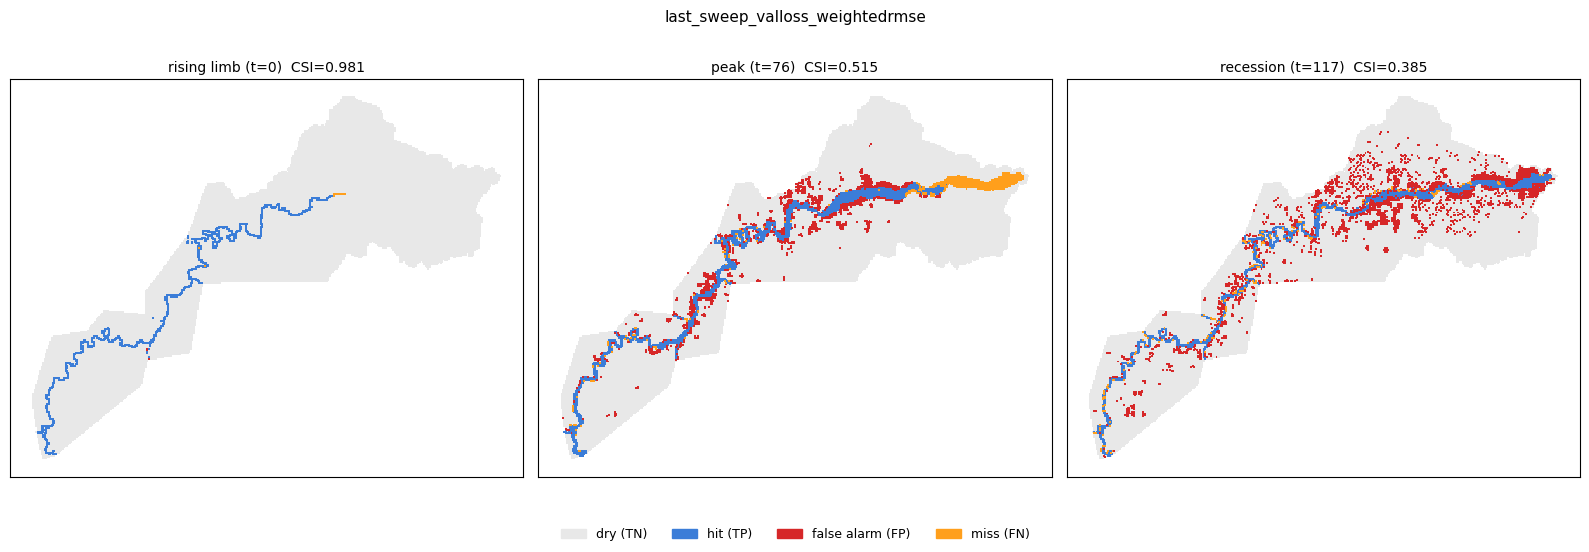

: 

In [ ]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

n_s0 = real_s0.shape[0]
pos_s0 = np.asarray(test_dataset[0].mesh.face_xy)[:n_s0]  # scale-0 nodes come first in the multiscale stack

cat_cmap = ListedColormap(['#e8e8e8', '#3b7dd8', '#d62728', '#ff9f1c'])  # TN, TP, FP, FN
legend_handles = [Patch(color=c, label=l) for c, l in zip(
    cat_cmap.colors, ['dry (TN)', 'hit (TP)', 'false alarm (FP)', 'miss (FN)'])]

for name, r in results.items():
    pred = r['plot_rollout']._predicted_rollout_s0[:, 0, :].cpu().numpy()
    real = r['plot_rollout']._real_rollout_s0[:, 0, :].cpu().numpy()
    fig, axes = plt.subplots(1, len(phases), figsize=(16, 5.5))
    for ax, (ph, t) in zip(axes, phases.items()):
        p, g = pred[:, t] > THR, real[:, t] > THR
        cat = np.zeros(n_s0, dtype=int)
        cat[p & g] = 1
        cat[p & ~g] = 2
        cat[~p & g] = 3
        order = np.argsort(cat, kind='stable')  # draw FP/FN on top of TP/TN
        ax.scatter(pos_s0[order, 0], pos_s0[order, 1], c=cat[order], cmap=cat_cmap,
                   vmin=0, vmax=3, s=2, marker='s', linewidths=0)
        csi_t = (p & g).sum() / max((p | g).sum(), 1)
        ax.set_title(f'{ph} (t={t})  CSI={csi_t:.3f}', fontsize=10)
        ax.set_aspect('equal')
        ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(name, fontsize=11)
    fig.legend(handles=legend_handles, loc='lower center', ncol=4, fontsize=9, frameon=False)
    plt.tight_layout(rect=[0, 0.04, 1, 1])
    plt.show()

### Fringe analysis — how far from the threshold are the errors?
Histograms of **real depth at missed cells (FN)** and **predicted depth at false alarms (FP)**.
If most mass sits within ~5 cm of the 0.05 m threshold, the CSI cap is a fringe-classification problem
(soft-CSI/Dice term + shallow_weight should help). If FN cells have substantial real depths (>0.15 m),
the model is genuinely under-predicting flooding and the fix is rollout drift / more training signal.

Model                            phase           #FP  FP near-thr    #FN  FN near-thr
finetune_weighted_rmse           rising limb    1290         27%    237          3%
finetune_weighted_rmse           peak           1395         13%    888          1%
finetune_weighted_rmse           recession      1278         22%    725          5%
best_sweep_weightedrmse          rising limb     785         31%    240          2%
best_sweep_weightedrmse          peak           1034         25%    735          1%
best_sweep_weightedrmse          recession      1380         41%    698          6%
finetune_weighted_rmse_extended  rising limb    3595         22%    238          3%
finetune_weighted_rmse_extended  peak           8597          4%    384          2%
finetune_weighted_rmse_extended  recession      6011         14%    521          8%
best_sweep_valloss_weightedrmse  rising limb     392         34%    282          2%
best_sweep_valloss_weightedrmse  peak            562         29%    701   

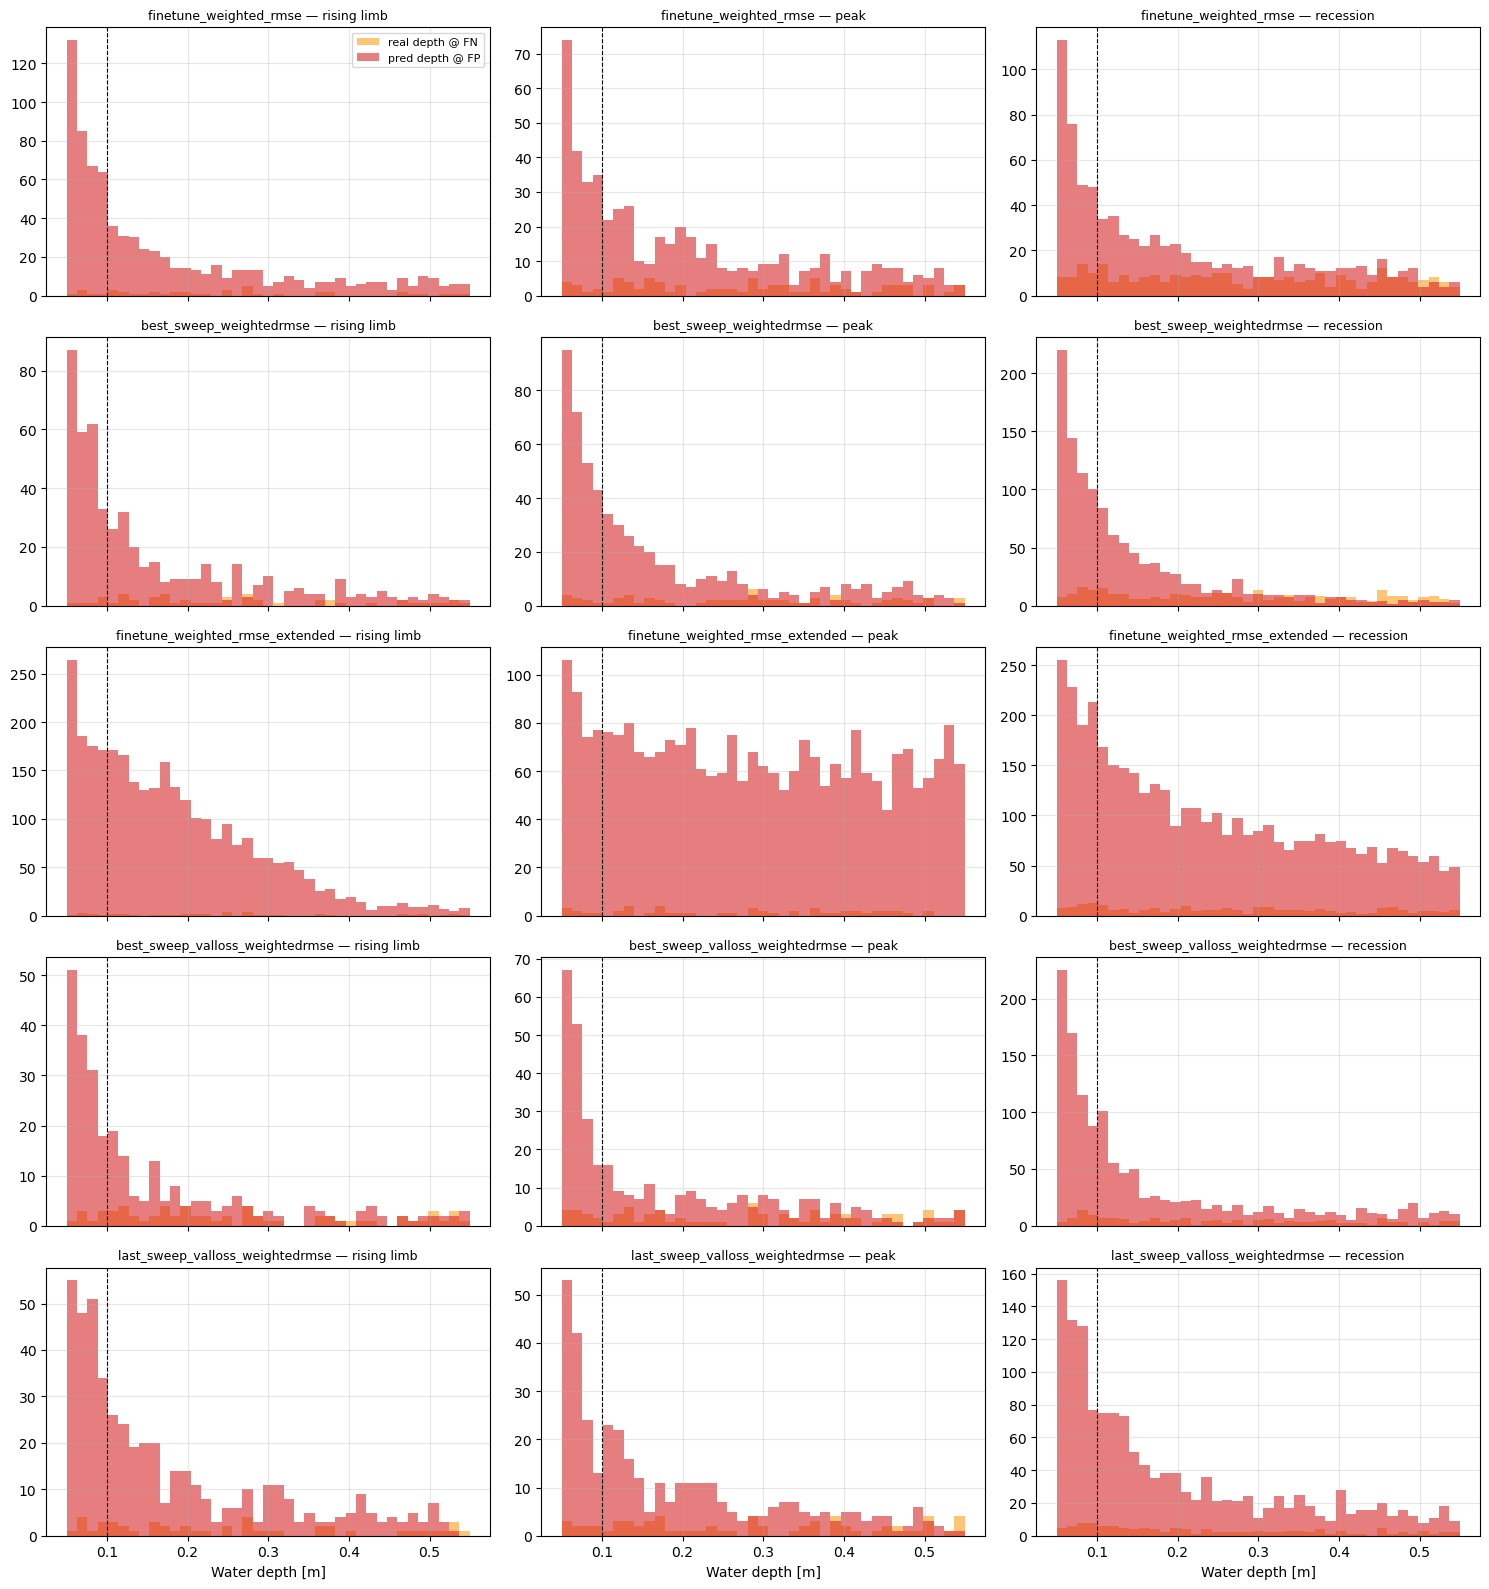

In [12]:
# Are misclassifications fringe cells (depth near the 5 cm threshold) or genuine misses?
BAND = 0.05  # near-threshold band [m]: cells within THR..THR+BAND count as "fringe"

print(f"{'Model':<32} {'phase':<12} {'#FP':>6} {'FP near-thr':>12} {'#FN':>6} {'FN near-thr':>12}")
fig, axes = plt.subplots(len(results), len(phases), figsize=(15, 3.2 * len(results)),
                         squeeze=False, sharex=True)
for i, (name, r) in enumerate(results.items()):
    pred = r['plot_rollout']._predicted_rollout_s0[:, 0, :].cpu().numpy()
    real = r['plot_rollout']._real_rollout_s0[:, 0, :].cpu().numpy()
    for j, (ph, t) in enumerate(phases.items()):
        p, g = pred[:, t] > THR, real[:, t] > THR
        fn_depth = real[~p & g, t]   # real depth at missed cells
        fp_depth = pred[p & ~g, t]   # predicted depth at false alarms
        ax = axes[i, j]
        bins = np.linspace(THR, THR + 0.5, 40)
        ax.hist(fn_depth, bins=bins, alpha=0.6, label='real depth @ FN', color='#ff9f1c')
        ax.hist(fp_depth, bins=bins, alpha=0.6, label='pred depth @ FP', color='#d62728')
        ax.axvline(THR + BAND, ls='--', c='k', lw=0.8)
        ax.set_title(f'{name} — {ph}', fontsize=9)
        ax.grid(alpha=0.3)
        fn_near = (fn_depth <= THR + BAND).mean() if len(fn_depth) else np.nan
        fp_near = (fp_depth <= THR + BAND).mean() if len(fp_depth) else np.nan
        print(f"{name:<32} {ph:<12} {len(fp_depth):>6} {fp_near:>11.0%} {len(fn_depth):>6} {fn_near:>11.0%}")
axes[0, 0].legend(fontsize=8)
for ax in axes[-1]:
    ax.set_xlabel('Water depth [m]')
plt.tight_layout()
plt.show()

## RMSE / CSI bar comparison

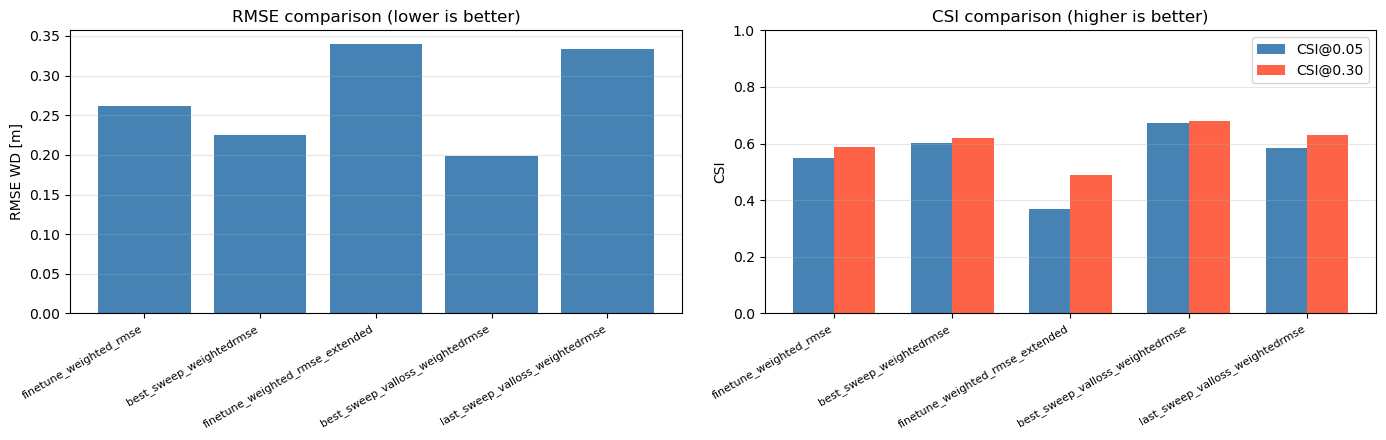

In [13]:
names = list(results.keys())
rmse_vals = [results[n]['rmse_wd'] for n in names]
csi005_vals = [results[n]['csi_005'] for n in names]
csi03_vals = [results[n]['csi_03'] for n in names]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
x = np.arange(len(names))

axes[0].bar(x, rmse_vals, color='steelblue')
axes[0].set_xticks(x)
axes[0].set_xticklabels(names, rotation=30, ha='right', fontsize=8)
axes[0].set_ylabel('RMSE WD [m]')
axes[0].set_title('RMSE comparison (lower is better)')
axes[0].grid(True, alpha=0.3, axis='y')

width = 0.35
axes[1].bar(x - width/2, csi005_vals, width, label='CSI@0.05', color='steelblue')
axes[1].bar(x + width/2, csi03_vals, width, label='CSI@0.30', color='tomato')
axes[1].set_xticks(x)
axes[1].set_xticklabels(names, rotation=30, ha='right', fontsize=8)
axes[1].set_ylabel('CSI')
axes[1].set_ylim(0, 1)
axes[1].set_title('CSI comparison (higher is better)')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Final-timestep flood map — all models side by side

--- finetune_weighted_rmse ---


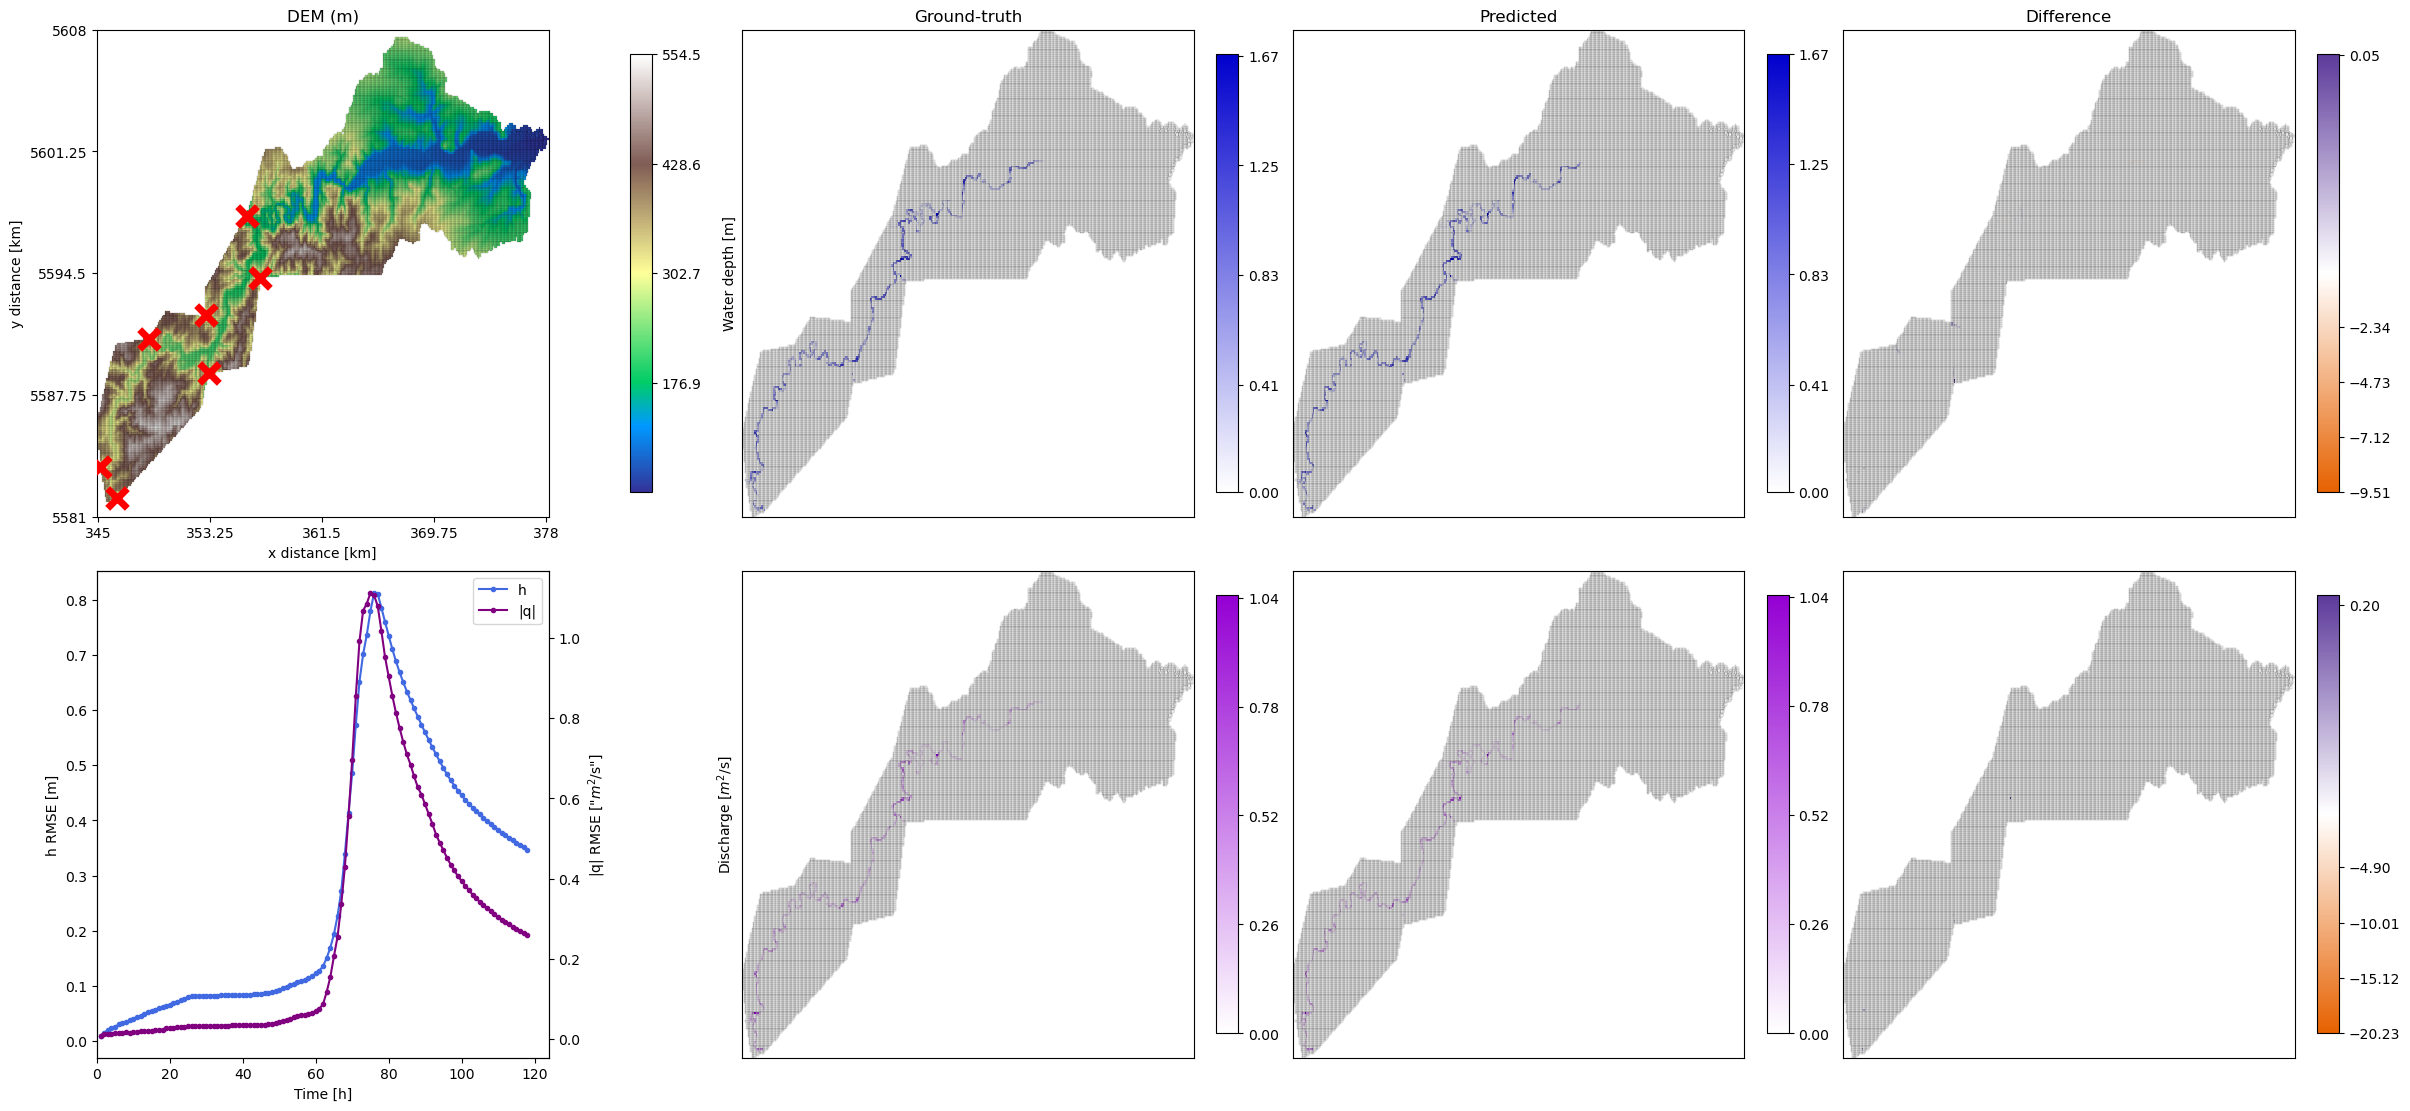

--- best_sweep_weightedrmse ---


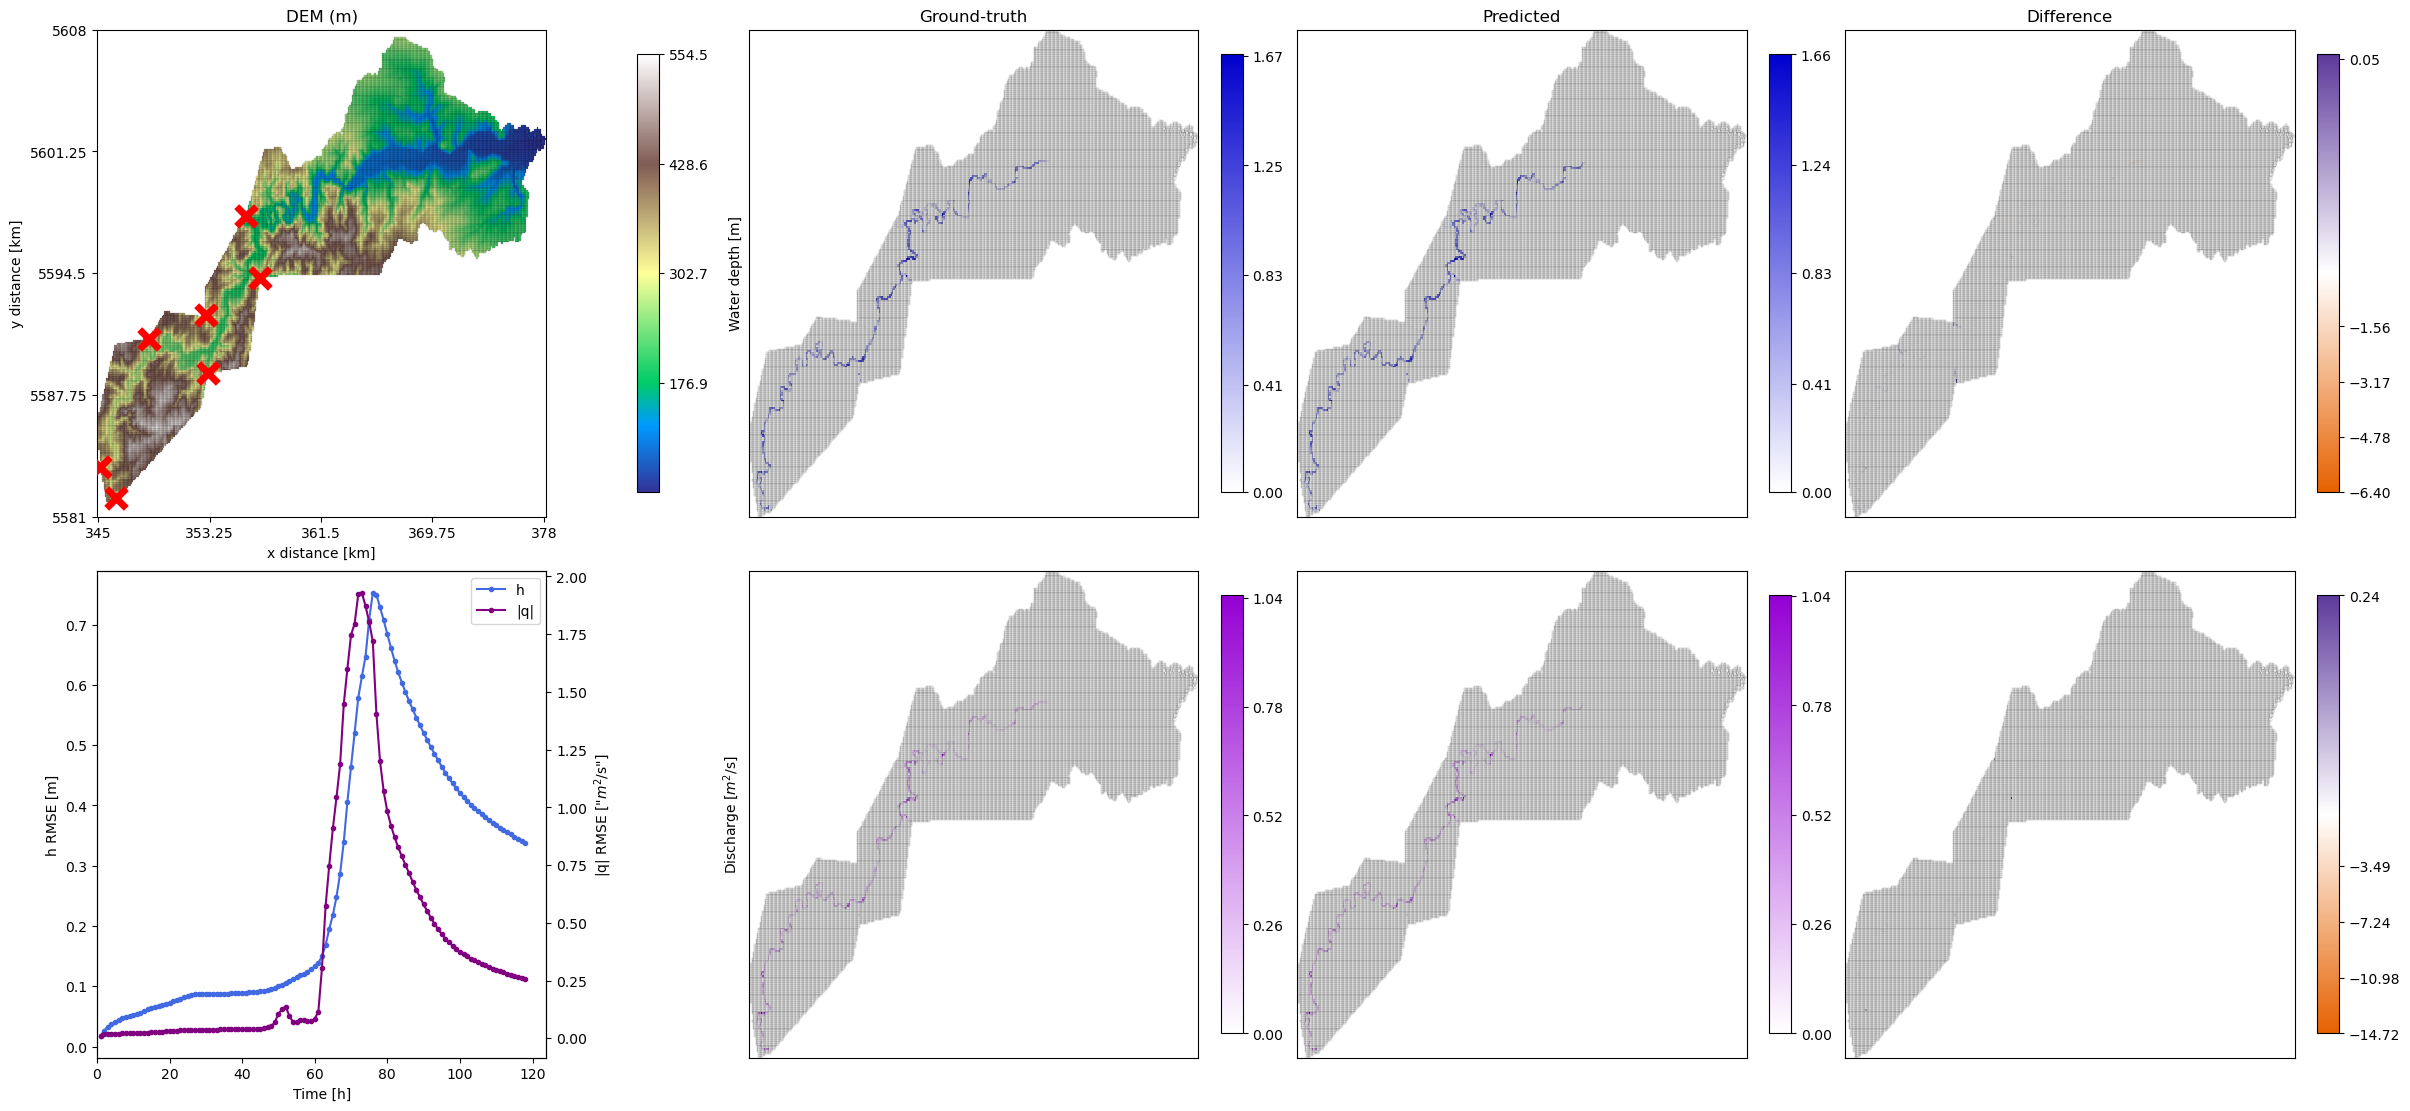

--- finetune_weighted_rmse_extended ---


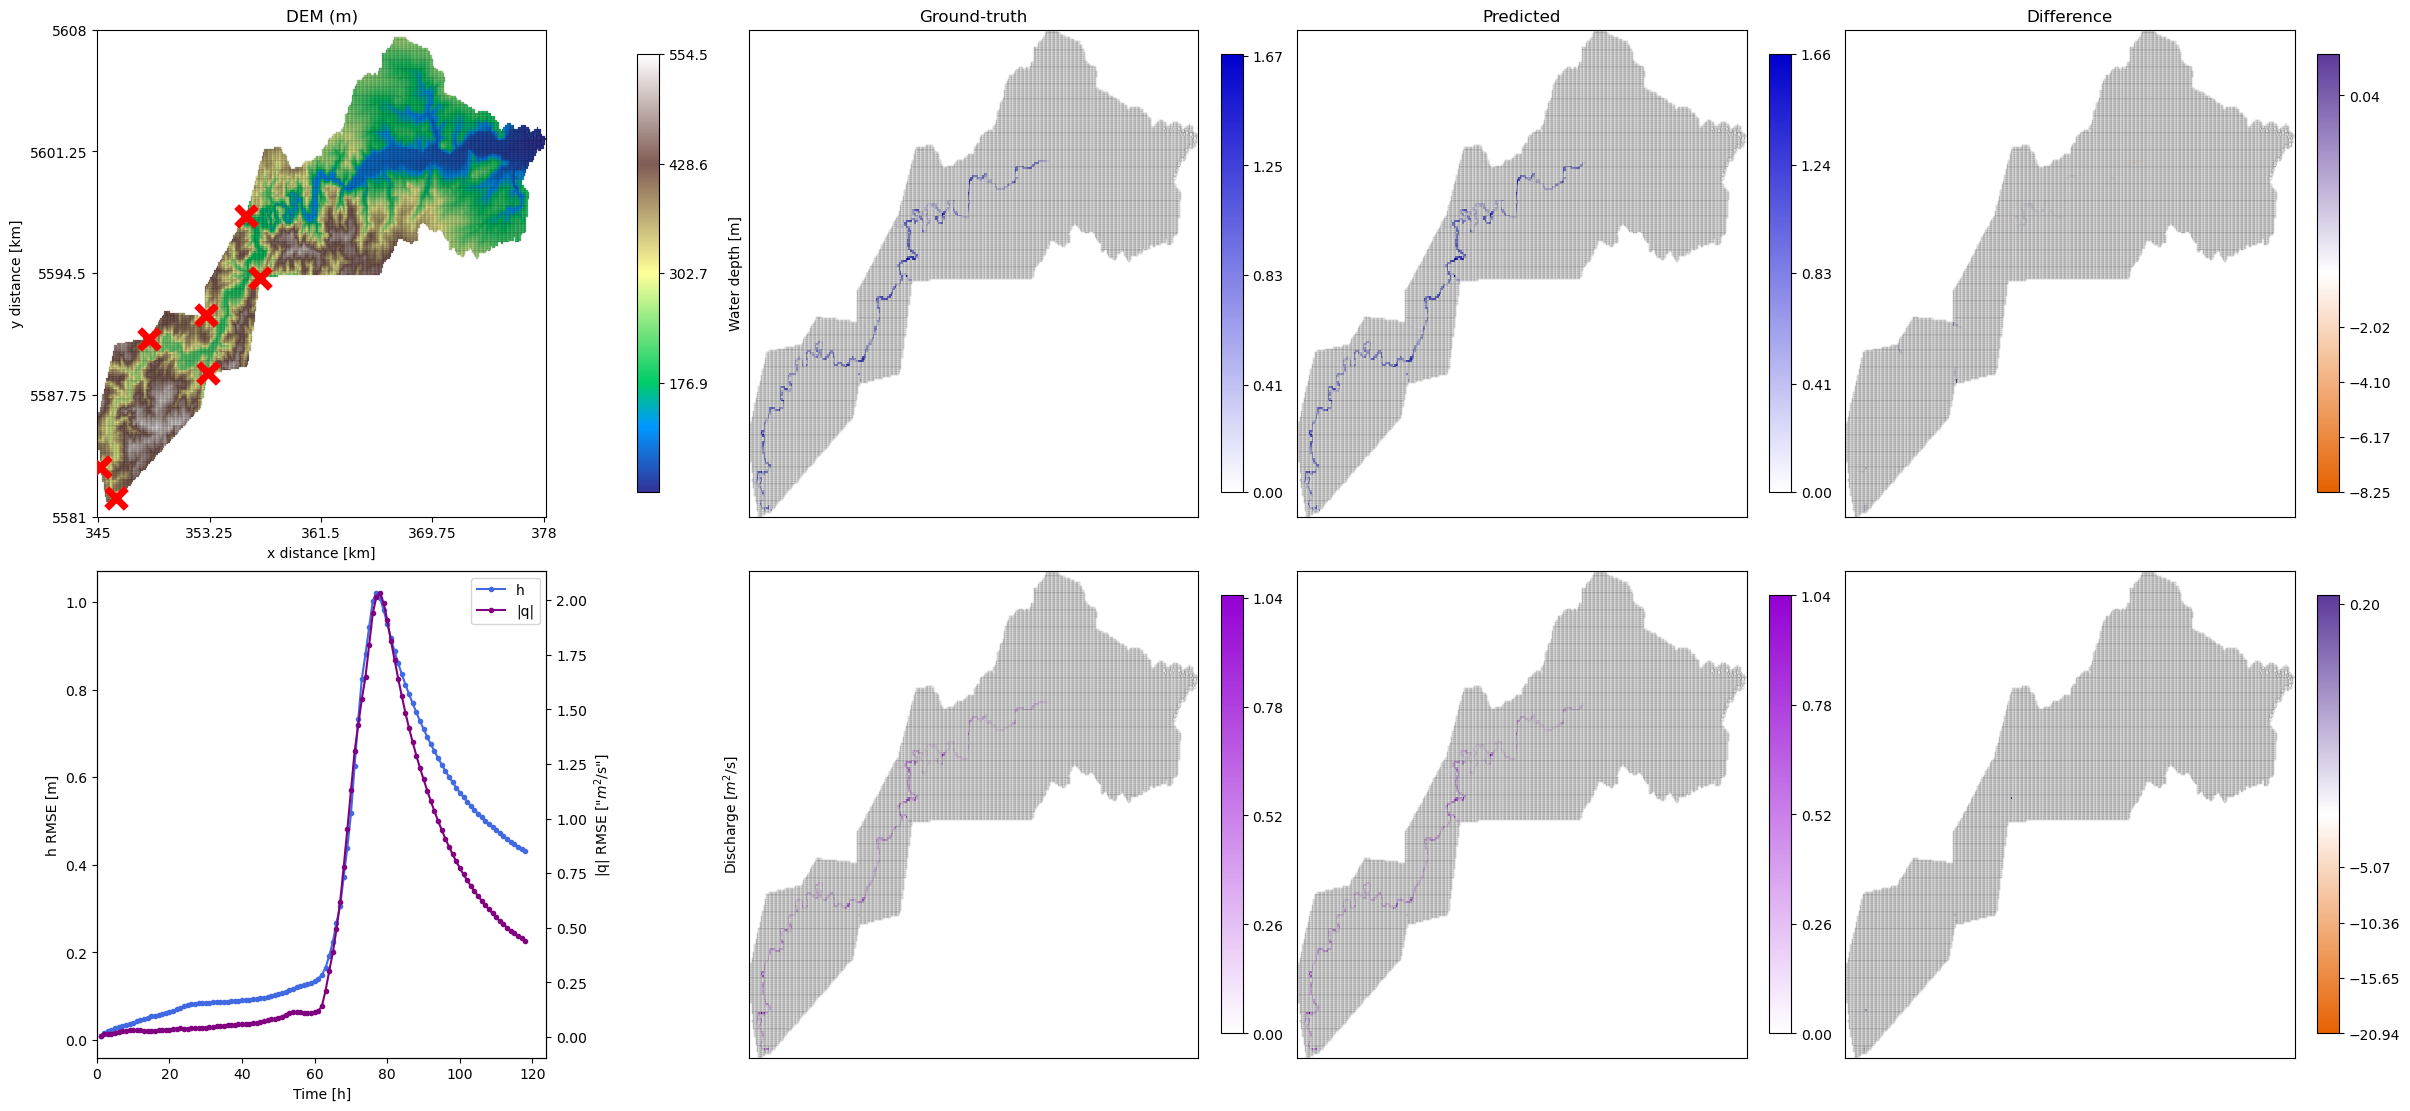

--- best_sweep_valloss_weightedrmse ---


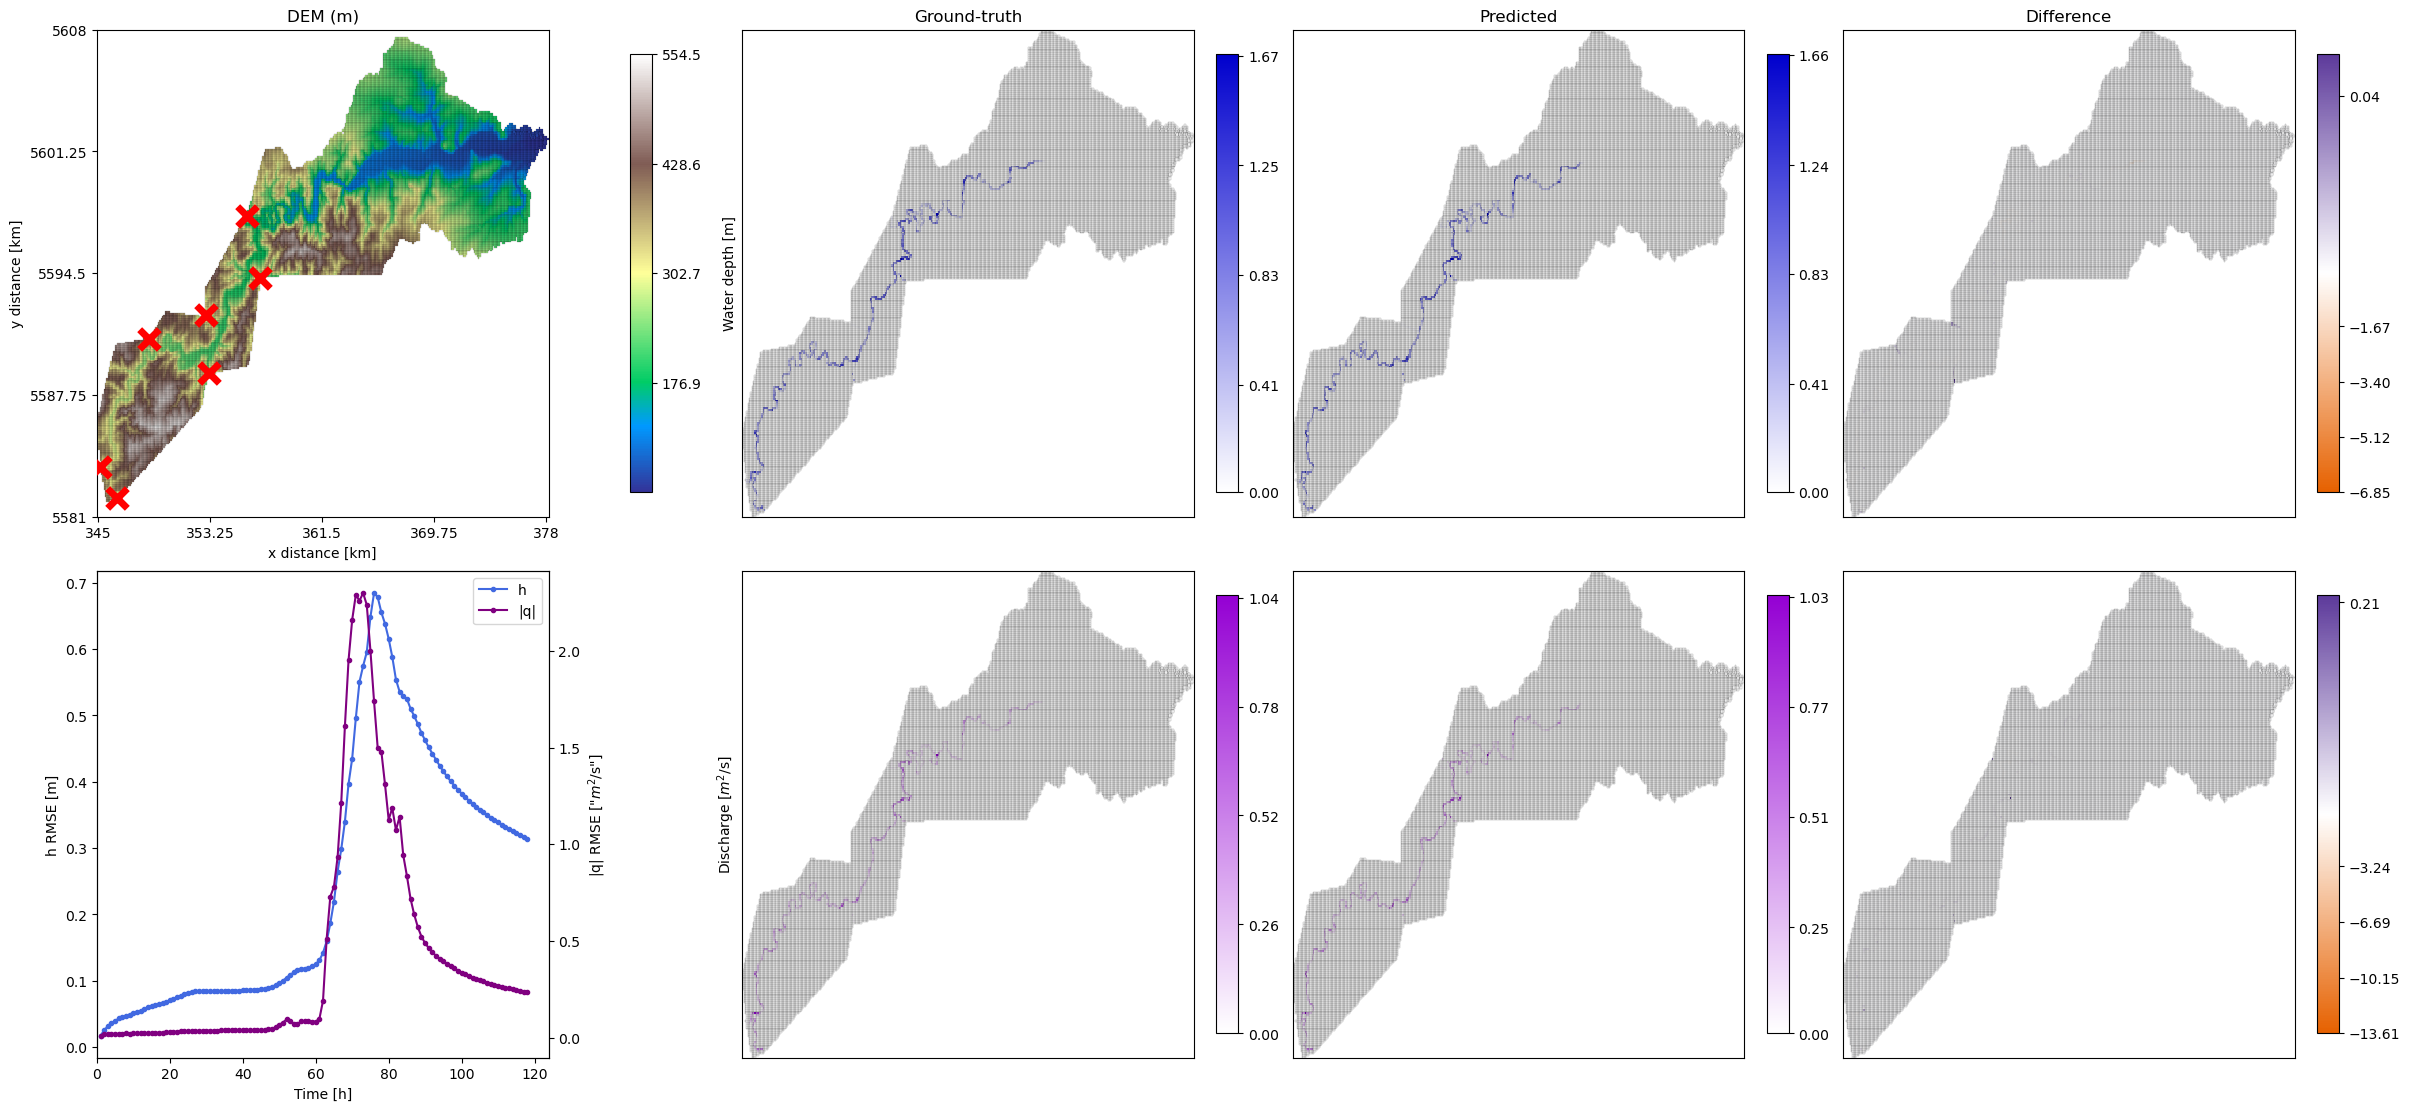

--- last_sweep_valloss_weightedrmse ---


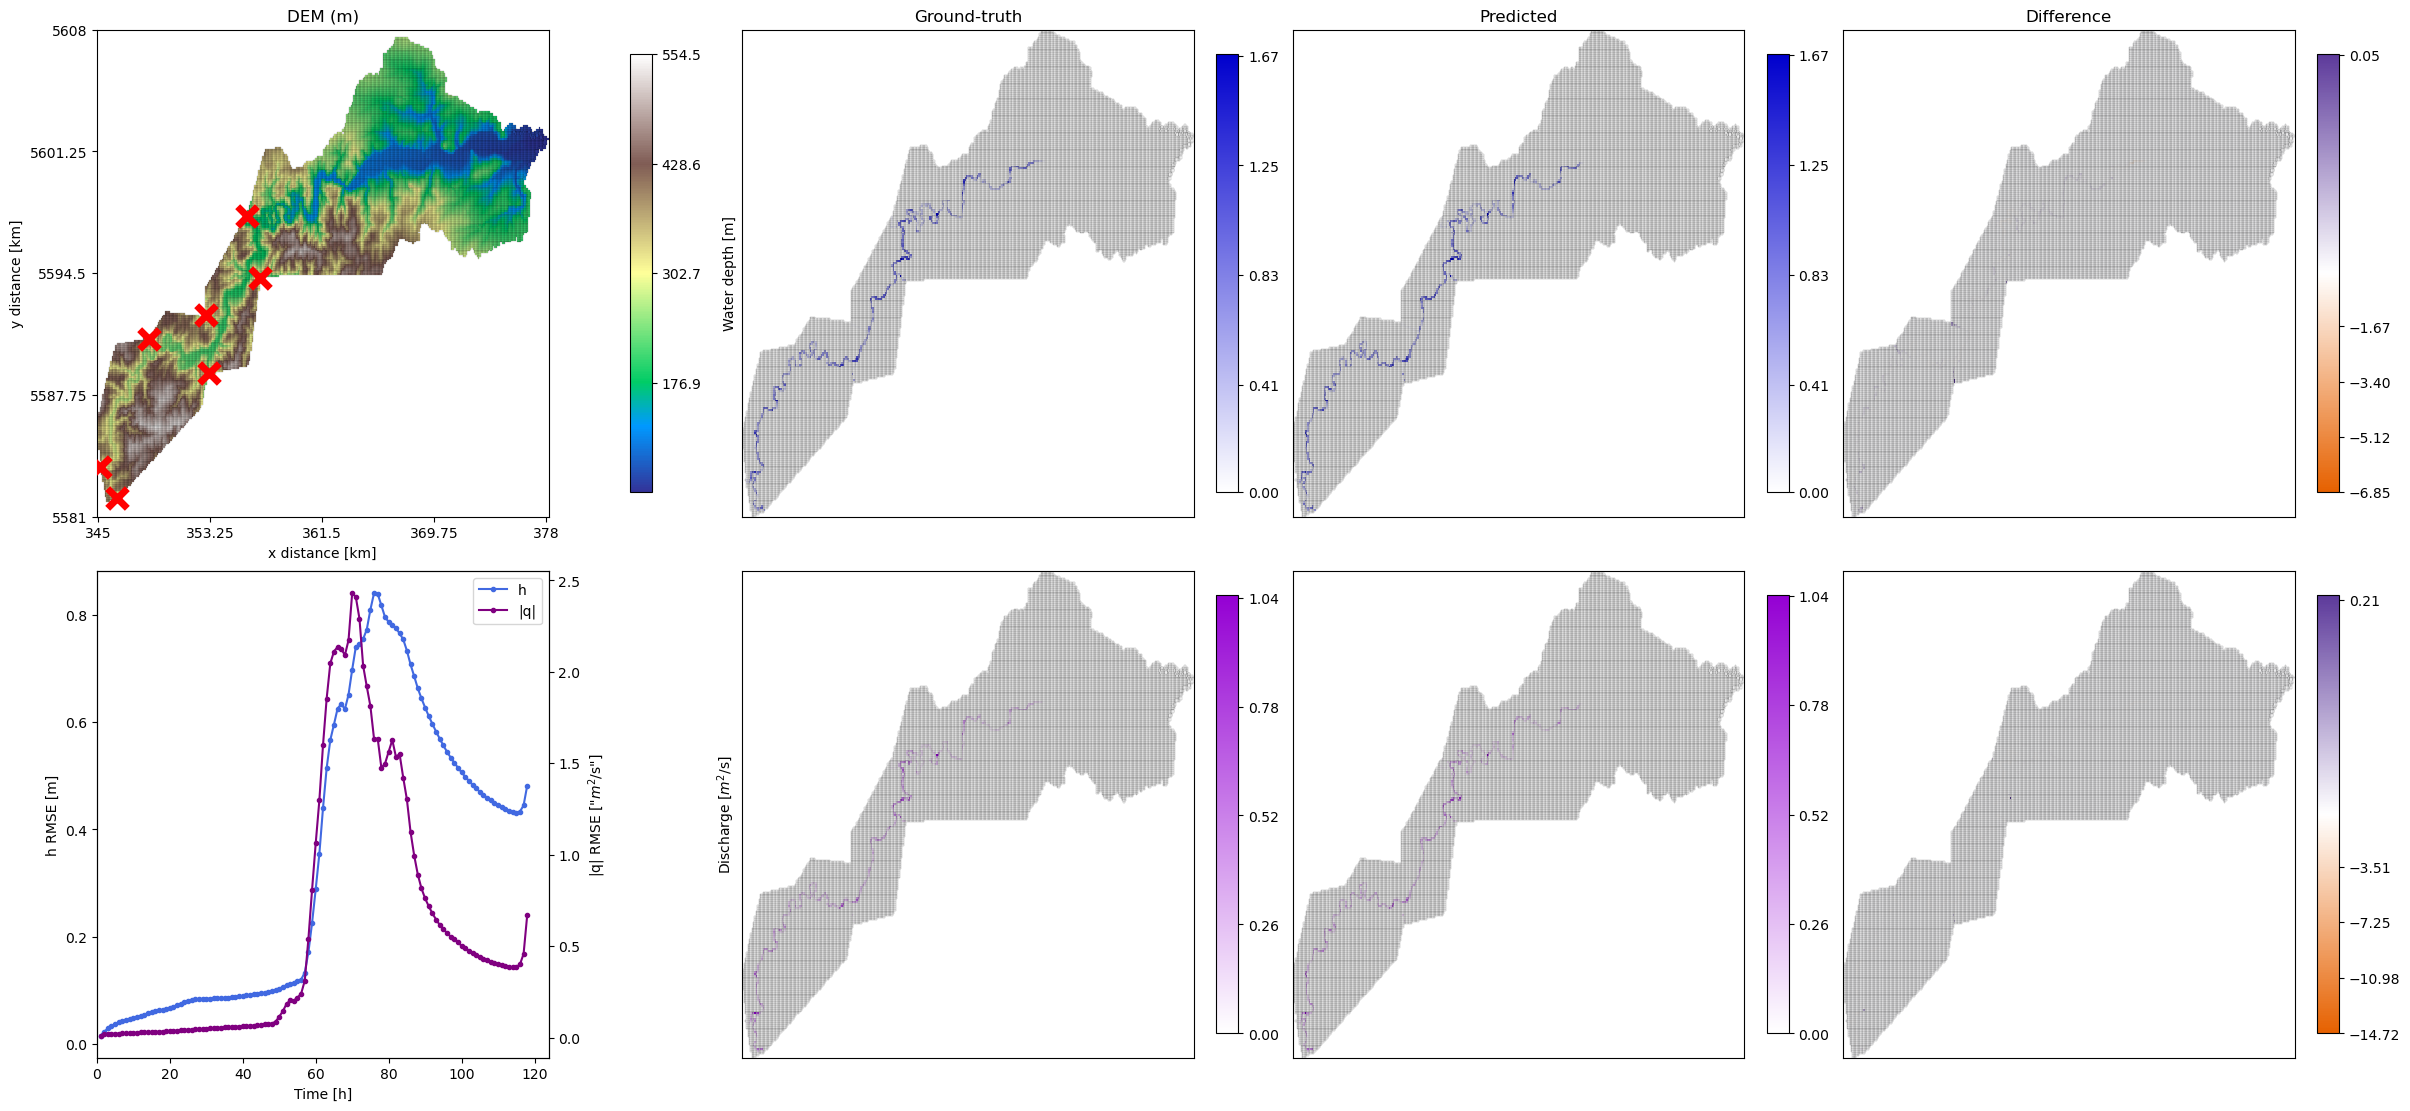

In [15]:
for name, r in results.items():
    print(f'--- {name} ---')
    fig = r['plot_rollout'].explore_rollout(scale=0, time_step=0)
    plt.show()